## Importing the dependencies

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


## Data Collection and processing

In [94]:
#loading the data from csv file to pandas dataframe
car_dataset=pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

In [95]:
#inspecting the first 5 lines
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [96]:
#checking the number of rows and columns
car_dataset.shape

(4340, 8)

In [97]:
#getting some informations about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


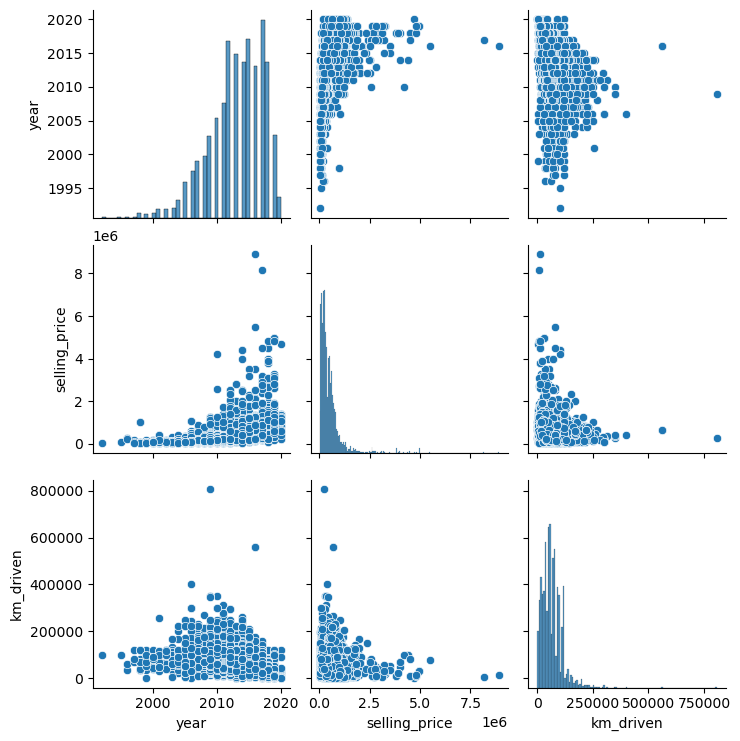

In [98]:
sns.pairplot(car_dataset)

In [99]:
#checking the number of missing values
car_dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [100]:
#checking the distribution of categorical data(They describe types or groups, not numbers.)
print(car_dataset.fuel.value_counts())
print('-----------------------')
print(car_dataset.seller_type.value_counts())
print('-----------------------')
print(car_dataset.transmission.value_counts())
print('-----------------------')
"""print(car_dataset.owner.value_counts())
print('-----------------------')"""

print(car_dataset.name.value_counts())


fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
-----------------------
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
-----------------------
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
-----------------------
name
Maruti Swift Dzire VDI                     69
Maruti Alto 800 LXI                        59
Maruti Alto LXi                            47
Maruti Alto LX                             35
Hyundai EON Era Plus                       35
                                           ..
Hyundai Verna Transform CRDi VGT SX ABS     1
Maruti S-Presso VXI Plus                    1
Toyota Etios Liva 1.2 VX                    1
Toyota Yaris G                              1
Hyundai i20 Magna 1.4 CRDi                  1
Name: count, Length: 1491, dtype: int64


In [101]:
# Afficher les statistiques descriptives
print("Statistiques descriptives :")
print(f"Moyenne : {car_dataset['selling_price'].mean():.2f}")
print(f"Médiane : {car_dataset['selling_price'].median():.2f}")
print(f"Écart-type : {car_dataset['selling_price'].std():.2f}")
print(f"Min : {car_dataset['selling_price'].min()}")
print(f"Max : {car_dataset['selling_price'].max()}")

Statistiques descriptives :
Moyenne : 504127.31
Médiane : 350000.00
Écart-type : 578548.74
Min : 20000
Max : 8900000


Text(0.5, 1.0, 'Boxplot des prix de vente')

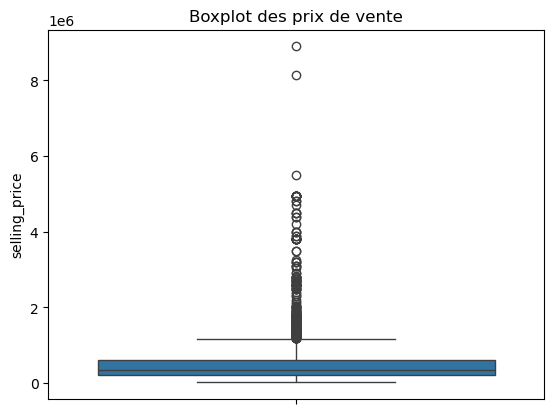

In [102]:
# Boxplot pour visualiser les outliers
sns.boxplot(y=car_dataset['selling_price'])
plt.title('Boxplot des prix de vente')

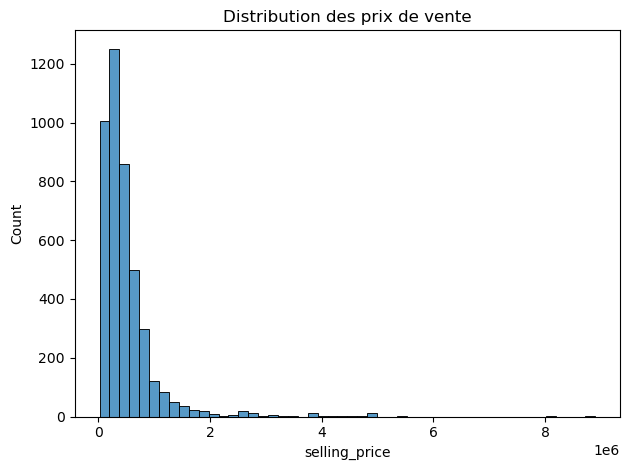

In [103]:
# Histogramme avec zoom
sns.histplot(car_dataset['selling_price'], bins=50)
plt.title('Distribution des prix de vente')
plt.tight_layout()
plt.show()

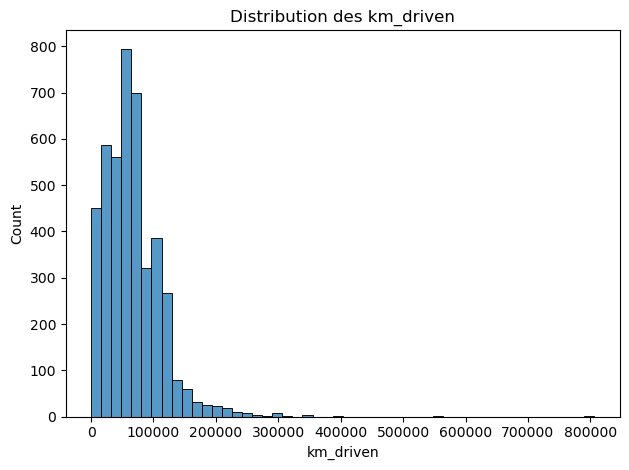

In [104]:
sns.histplot(car_dataset['km_driven'], bins=50)
plt.title('Distribution des km_driven')
plt.tight_layout()
plt.show()

In [105]:
#Identifier précisément les outliers prices
# Méthode 1: IQR (Interquartile Range)
Q1 = car_dataset['selling_price'].quantile(0.25)
Q3 = car_dataset['selling_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_p = Q1 - 1*IQR
upper_bound_p = Q3 + 1*IQR

outliers_iqr_prices = car_dataset[(car_dataset['selling_price'] < lower_bound_p) | (car_dataset['selling_price'] > upper_bound_p)]
print(f"Nombre d'outliers prices (méthode IQR): {len(outliers_iqr_prices)}")


print("\nOutliers les plus élevés :")
print(outliers_iqr_prices['selling_price'].sort_values(ascending=False).head(20))

#Identifier précisément les outliers km_driven
# Méthode 1: IQR (Interquartile Range)
Q11 = car_dataset['km_driven'].quantile(0.25)
Q33 = car_dataset['km_driven'].quantile(0.75)
IQRk = Q33 - Q11
lower_bound_k = Q11 - 1*IQRk
upper_bound_k = Q33 + 1*IQRk

outliers_iqr_km = car_dataset[(car_dataset['km_driven'] < lower_bound_k) | (car_dataset['km_driven'] > upper_bound_k)]
print(f"Nombre d'outliers km_driven (méthode IQR): {len(outliers_iqr_km)}")


print("\nOutliers les plus élevés :")
print(outliers_iqr_km['km_driven'].sort_values(ascending=False).head(20))

Nombre d'outliers prices (méthode IQR): 376

Outliers les plus élevés :
3872    8900000
89      8150000
3969    5500000
2258    4950000
2739    4950000
919     4950000
1023    4950000
612     4950000
1836    4950000
574     4950000
2239    4950000
555     4950000
593     4950000
900     4950000
3883    4800000
3453    4800000
963     4700000
101     4500000
2580    4500000
4047    4500000
Name: selling_price, dtype: int64
Nombre d'outliers km_driven (méthode IQR): 195

Outliers les plus élevés :
1243    806599
525     560000
4184    560000
3679    400000
69      350000
2394    350000
3718    347089
1674    312000
3898    300000
1101    300000
3994    300000
3646    300000
1659    300000
2964    296823
3675    295000
3979    280000
2961    270000
2401    267000
3171    260000
4208    256000
Name: km_driven, dtype: int64


Text(0.5, 1.0, 'Distribution après transformation log')

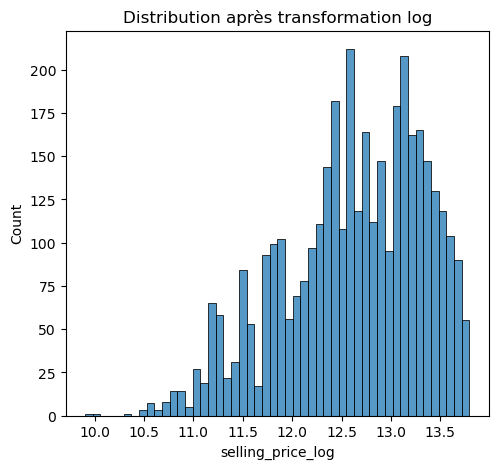

In [106]:
#Transformation logarithmique
df_clean = car_dataset[
    (car_dataset['selling_price'] >= lower_bound_p) & 
    (car_dataset['selling_price'] <= upper_bound_p) &
    (car_dataset['km_driven'] >= lower_bound_k) & 
    (car_dataset['km_driven'] <= upper_bound_k)
]
df_log = df_clean.copy()
df_log['selling_price_log'] = np.log1p(df_clean['selling_price'])  # log(1+x) pour gérer les zéros
df_log['km_driven_log'] = np.log1p(df_clean['km_driven']) 


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_log['selling_price_log'], bins=50)
plt.title('Distribution après transformation log')

In [107]:
# 1. Vérifiez combien de données vous gardez :
print(f"Données originales: {len(car_dataset)}")
print(f"Après votre nettoyage: {len(df_clean)}")
print(f"Pourcentage gardé: {len(df_clean)/len(car_dataset)*100:.1f}%")

# Si < 70%, vous supprimez TROP!
if len(df_clean) / len(car_dataset) < 0.7:
    print("❌ Vous supprimez trop de données!")
    print("→ Essayez IQR avec multiplier=2.0 au lieu de 1.5")

Données originales: 4340
Après votre nettoyage: 3778
Pourcentage gardé: 87.1%


## Encoding the categorical Data : 

transforming text or label values into numbers because machine learning models only understand numbers, not words or text.

**Why is it necessary?**

Most ML algorithms (like Linear Regression, Logistic Regression, SVM, KNN, etc.) work with mathematical equations.

In [108]:
#encoding "fuel" column
df_log.replace({'fuel': {'Diesel':0,'Petrol':1, 'CNG':2,'LPG':3,'Electric':4}},inplace=True)
df_log.replace({'seller_type': {'Individual':0,'Dealer':1, 'Trustmark Dealer':2}},inplace=True)
df_log.replace({'transmission': {'Manual':0,'Automatic':1}},inplace=True)
df_log.replace({'owner': {'First Owner':0,'Second Owner':1, 'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4}},inplace=True)

/tmp/ipykernel_9492/185692947.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_log.replace({'fuel': {'Diesel':0,'Petrol':1, 'CNG':2,'LPG':3,'Electric':4}},inplace=True)
/tmp/ipykernel_9492/185692947.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_log.replace({'seller_type': {'Individual':0,'Dealer':1, 'Trustmark Dealer':2}},inplace=True)
/tmp/ipykernel_9492/185692947.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call

RQ : 

**inplace=False** (valeur par défaut)
→ crée une nouvelle copie du DataFrame modifié
→ l’objet original n’est pas changé

**inplace=True**
→ modifie directement le DataFrame d’origine
→ ne retourne rien (None)

In [109]:
df_log.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,selling_price_log,km_driven_log
0,Maruti 800 AC,2007,60000,70000,1,0,0,0,11.002117,11.156265
1,Maruti Wagon R LXI Minor,2007,135000,50000,1,0,0,0,11.813037,10.819798
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,0,0,0,13.304687,11.512935
3,Datsun RediGO T Option,2017,250000,46000,1,0,0,0,12.429220,10.736418
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,0,0,1,13.017005,11.856522


In [110]:
# La colonne 'name' contient souvent : "Toyota Corolla 2015" ou "BMW X5 2020"
# On extrait juste la marque :

def extract_brand(name):
    return name.split()[0]  # Premier mot = marque


df_log['brand'] = df_log['name'].apply(extract_brand)

# Encodage simple de la marque
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_log['brand_encoded'] = le.fit_transform(df_log['brand'])

print(f"Nombre de marques uniques : {df_log['brand'].nunique()}")
# Typiquement 20-50 marques → parfait pour l'encodage!

Nombre de marques uniques : 22


In [111]:
df_log['age'] = 2024 - df_log['year']
df_log['km_per_year'] = df_log['km_driven'] / (df_log['age'] + 1)
#

In [112]:
df_log.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,selling_price_log,km_driven_log,brand,brand_encoded,age,km_per_year
0,Maruti 800 AC,2007,60000,70000,1,0,0,0,11.002117,11.156265,Maruti,12,17,3888.888889
1,Maruti Wagon R LXI Minor,2007,135000,50000,1,0,0,0,11.813037,10.819798,Maruti,12,17,2777.777778
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,0,0,0,13.304687,11.512935,Hyundai,10,12,7692.307692
3,Datsun RediGO T Option,2017,250000,46000,1,0,0,0,12.429220,10.736418,Datsun,5,7,5750.000000
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,0,0,1,13.017005,11.856522,Honda,9,10,12818.181818


In [113]:
Q1y = df_log['km_per_year'].quantile(0.25)
Q3y = df_log['km_per_year'].quantile(0.75)
IQRy = Q3y - Q1y
lower_bound_y = Q1y - 1*IQRy
upper_bound_y = Q3y + 1*IQRy

outliers_iqr_y = df_log[(df_log['km_per_year'] < lower_bound_y) | (df_log['km_per_year'] > upper_bound_y)]
print(f"Nombre d'outliers prices (méthode IQR): {len(outliers_iqr_y)}")


print("\nOutliers les plus élevés :")
print(outliers_iqr_y['km_per_year'].sort_values(ascending=False).head(20))

Nombre d'outliers prices (méthode IQR): 135

Outliers les plus élevés :
158     24000.000000
2013    20000.000000
1371    20000.000000
2137    18000.000000
2103    17500.000000
3492    17500.000000
435     17142.857143
2553    15436.111111
1172    15000.000000
2811    15000.000000
1817    15000.000000
2925    15000.000000
106     15000.000000
980     14500.000000
4205    14073.000000
240     14000.000000
2978    14000.000000
1953    13888.888889
3454    13750.000000
3321    13750.000000
Name: km_per_year, dtype: float64


In [114]:
df_log = df_log[
    (df_log['km_per_year'] >= lower_bound_y) & 
    (df_log['km_per_year'] <= upper_bound_y) 
    
]
df_log['km_per_year_log'] = np.log1p(df_log['km_per_year'])

# Check data linearity

## Correlation Check

In [115]:
Z= df_log.drop(['name', 'brand','selling_price','km_driven','km_per_year'], axis=1)
Z.corr()['selling_price_log'].sort_values(ascending=False)

selling_price_log    1.000000
year                 0.745844
seller_type          0.274668
transmission         0.168808
brand_encoded        0.002055
km_per_year_log     -0.027571
km_driven_log       -0.320616
fuel                -0.325742
owner               -0.361874
age                 -0.745844
Name: selling_price_log, dtype: float64

## Visual Checks: 

If the points roughly follow a straight line → ✅ linear relationship.

If they form a curve, wave, plateau, or random shape → ❌ nonlinear.

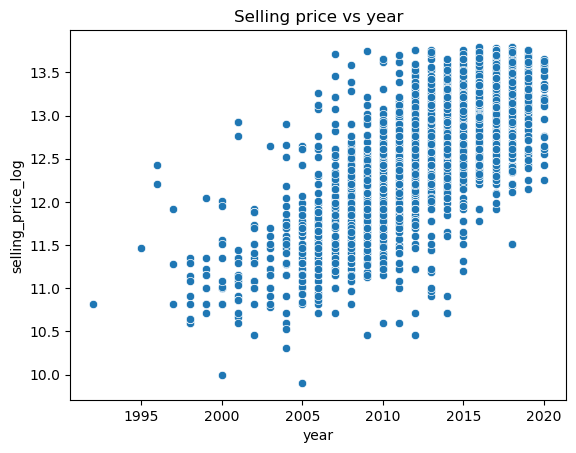

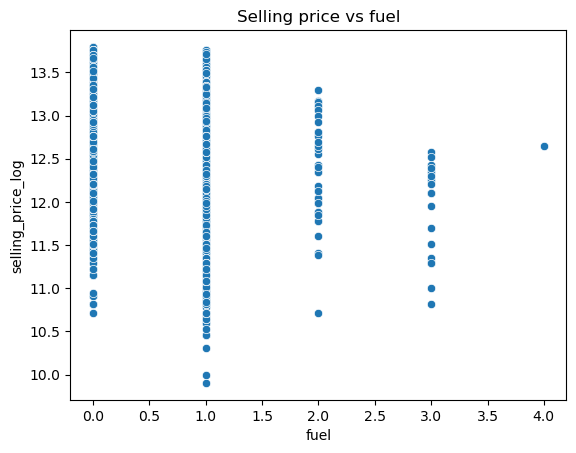

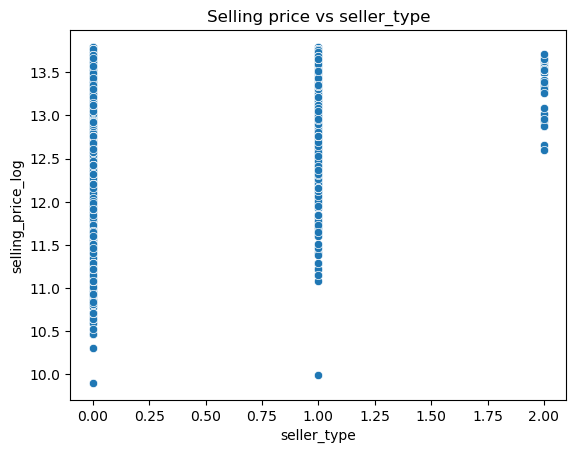

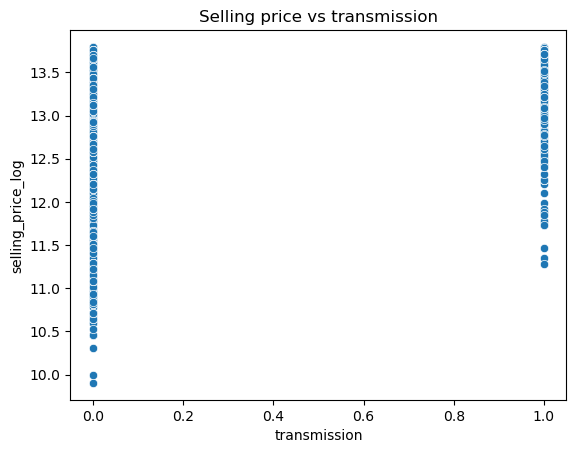

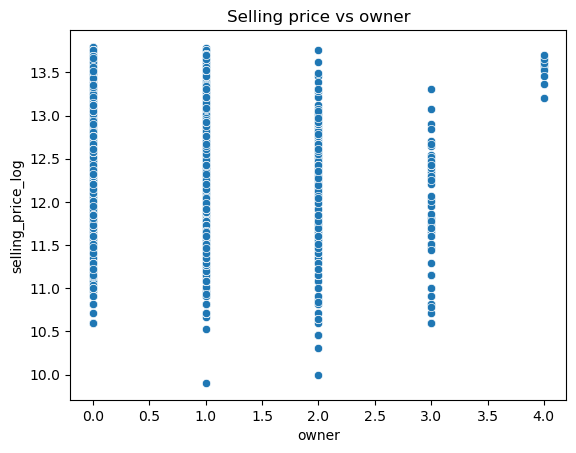

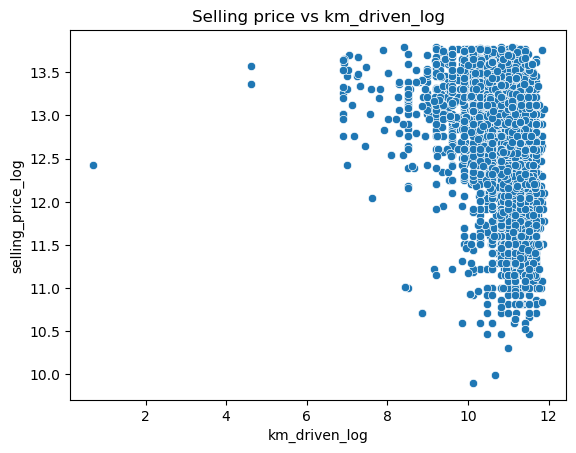

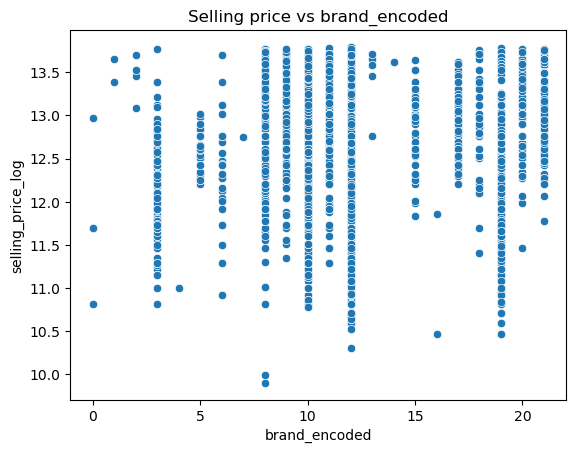

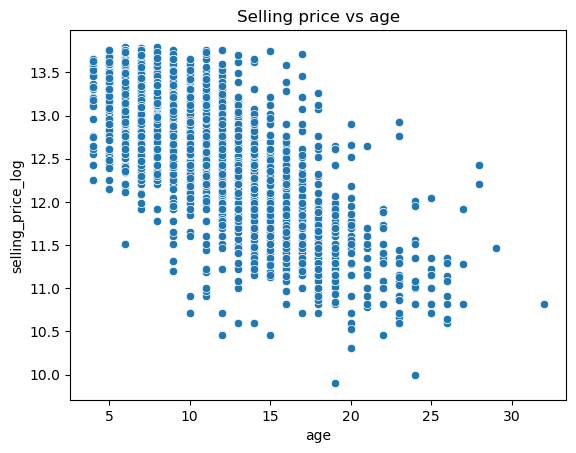

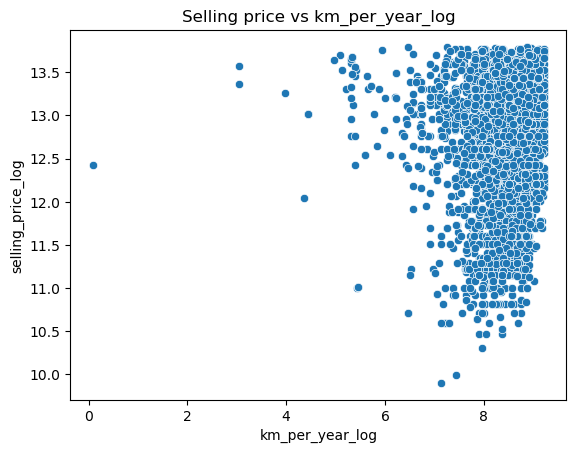

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in Z.select_dtypes(include=['number']).columns:
    if col != 'selling_price_log':
        sns.scatterplot(x=Z[col], y=Z['selling_price_log'])
        plt.title(f"Selling price vs {col}")
        plt.show()


Relations Apparemment Linéaires :

    ✅ Price vs Year : Relation décroissante relativement linéaire

    ✅ Price vs km_driven_log : Relation inverse relativement linéaire

Relations Clairement NON Linéaires :

    ❌ Price vs Fuel : Distribution non linéaire (catégorielle)

    ❌ Price vs Seller_type : Distribution non uniforme

    ❌ Price vs Transmission : Deux groupes distincts (catégoriel)

    ❌ Price vs Owner : Relations complexes, non linéaires

    ❌ Price vs Brand_encoded : Relations variables par marque

Conclusion : VOS DONNÉES SONT MAJORITAIREMENT NON LINÉAIRES


# Separate features(X) and target(Y)

In [117]:
X= df_log.drop(['name', 'brand','selling_price','selling_price_log','km_driven','km_per_year'], axis=1)
#we drop 'name' column because it is not helpful for the price prediction 
Y=df_log['selling_price_log'] #it is the value that we will predict

In [118]:
print(X)

      year  fuel  seller_type  transmission  owner  km_driven_log  \
0     2007     1            0             0      0      11.156265   
1     2007     1            0             0      0      10.819798   
2     2012     0            0             0      0      11.512935   
3     2017     1            0             0      0      10.736418   
5     2007     1            0             0      0      11.736077   
...    ...   ...          ...           ...    ...            ...   
4335  2014     0            0             0      1      11.289794   
4336  2014     0            0             0      1      11.289794   
4337  2009     1            0             0      1      11.326608   
4338  2016     0            0             0      0      11.407576   
4339  2016     1            0             0      0      10.596660   

      brand_encoded  age  km_per_year_log  
0                12   17         8.266136  
1                12   17         7.929766  
2                10   12         8.9481

In [119]:
print(Y)

0       11.002117
1       11.813037
2       13.304687
3       12.429220
5       11.849405
          ...    
4335    12.923912
4336    12.923912
4337    11.608245
4338    13.670486
4339    12.323860
Name: selling_price_log, Length: 3643, dtype: float64


# Splitting Training and Test Data

When you build a ml model, you want to know how well it performs on new, unseen data — not just on the data it has already seen.

So, we divide our dataset into two parts:

**Training set** → used to train the model (learn patterns).

**Test set** → used to evaluate the model (check accuracy on unseen data).

**train_test_split()** randomly divides your data into training and test subsets.

**test_size=0.1** means 10% of data is used for testing.

**random_state=2** : every time you run your code, you get the same random split.

In [120]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.1, random_state=2)

# Model Training

1. Create an empty Linear Regression model 

lin_reg_model is an object that **contains the algorithm** and will *later* store the model’s learned parameters (weights and bias).

In [121]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

lin_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
#loading the linear regression model
#lin_reg_model=LinearRegression()
#lin_reg_model = Ridge(alpha=1.0)

2. **Train the model** — find the best coefficients (slopes) and intercept (bias) that minimize prediction error.

In [122]:

lin_reg_model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Model Evaluation

In [123]:
#prediction on training data
training_data_prediction=lin_reg_model.predict(X_train)


In [124]:
y_pred_original = np.expm1(training_data_prediction)
y_train_original = np.expm1(Y_train)


## Residual analysis

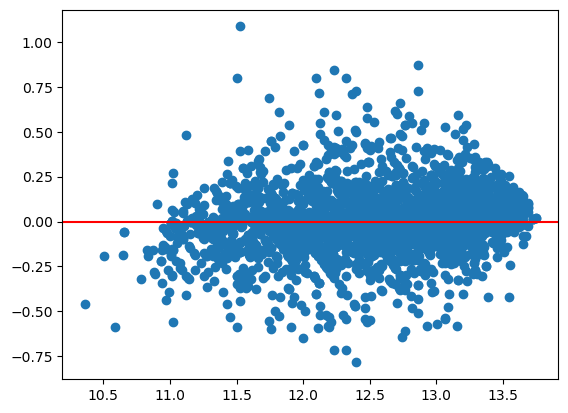

In [125]:
residuals = Y_train - training_data_prediction
plt.scatter(training_data_prediction, residuals)
plt.axhline(0, color='red')
plt.show()


In [ ]:
#R-squared error
r2_score=metrics.r2_score(y_train_original,y_pred_original)
print("R-squared Error : ",r2_score )


mape = np.mean(np.abs((y_train_original - y_pred_original) / y_train_original)) * 100
print(mape)
# 2. Interprétez :
if mape < 10:
    print("✅ Excellent! Votre modèle prédit à moins de 10% près")
elif mape < 20:
    print("✅ Très bon! Prédiction à moins de 20% près")  
elif mape < 30:
    print("⚠️ Acceptable pour un premier projet")
else:
    print("❌ Besoin d'amélioration")

R-squared Error :  0.9262729279809239
11.480977303481666
✅ Très bon! Prédiction à moins de 20% près


## Visualisation

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices')

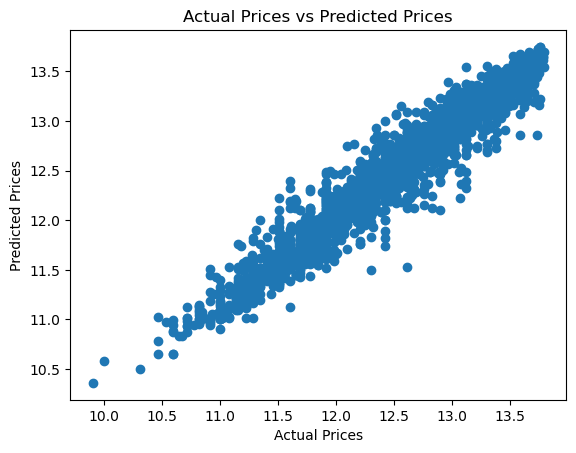

In [127]:
#log
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices')

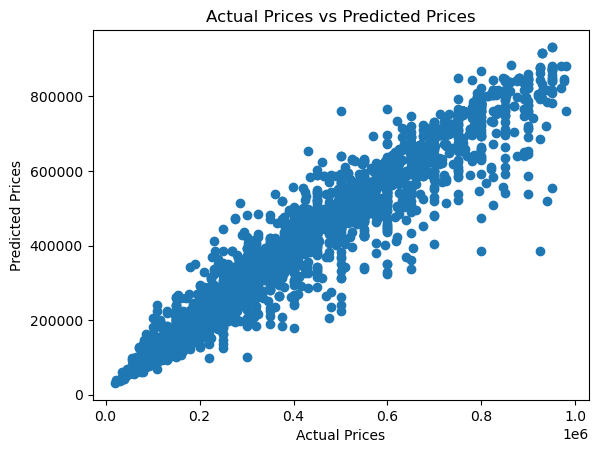

In [128]:
#original
plt.scatter(y_train_original,y_pred_original)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")

In [129]:
#prediction on test data
test_data_prediction=lin_reg_model.predict(X_test)

In [130]:
y_pred_test_original=np.expm1(test_data_prediction)
y_test_original=np.expm1(Y_test)

In [131]:
#R-squared error
error_score=metrics.r2_score(y_test_original,y_pred_test_original)
print("R-squared Error : ",error_score )

R-squared Error :  0.680944654019966


Text(0.5, 1.0, 'Actual Prices vs Predicted Prices')

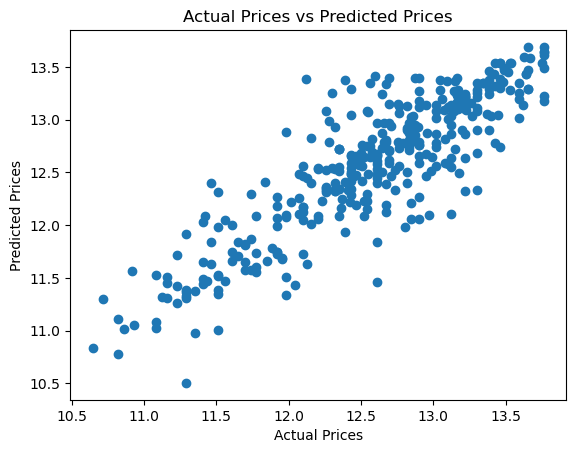

In [132]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices')

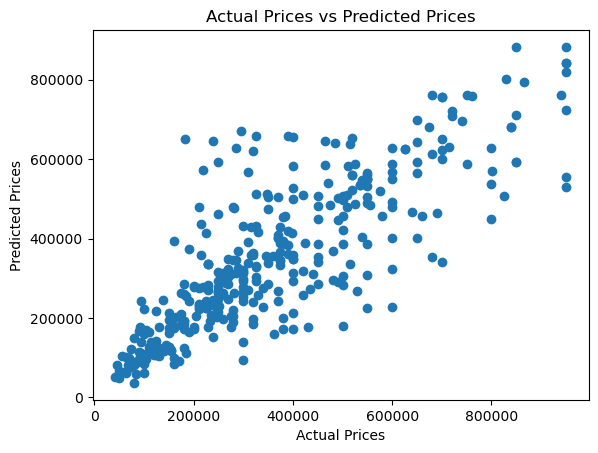

In [133]:
plt.scatter(y_test_original,y_pred_test_original)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")